In [1]:
import numpy as np

def ratio(N):
    h = 1.0/(N+1)
    n1, n2 = 1, 2
    lam1 = 4/h**2 * np.sin(n1*np.pi/(2*(N+1)))**2
    lam2 = 4/h**2 * np.sin(n2*np.pi/(2*(N+1)))**2
    return lam2/lam1

for N in [8, 16, 32, 64, 128, 256, 512, 1024]:
    print(N, ratio(N))
# target continuum ratio = 4.0

8 3.8793852415718164
16 3.9659461993678047
32 3.990943845146169
64 3.9976644536646537
128 3.999406939690279
256 3.999850573339465
512 3.9999624972031054
1024 3.9999906059758006


In [2]:
import jax
import jax.numpy as jnp
from functools import partial

@partial(jax.jit, static_argnums=(1,))
def langevin_step(theta, grad_fn, key, dt):
    key, sub = jax.random.split(key)
    noise = jax.random.normal(sub, theta.shape, dtype=theta.dtype)
    theta_new = theta - dt * grad_fn(theta) + jnp.sqrt(2.0*dt) * noise
    return theta_new, key

def langevin_hitting_time(L, beta, c0, scale0,
                          dt=2e-3, max_steps=4000, check_every=50,
                          seed=0, k_lanczos=25):
    flat_action, _ = make_flat_funcs(L, beta, c0)
    grad_fn = jax.jit(jax.grad(flat_action))

    key = jax.random.PRNGKey(seed)
    key, sub = jax.random.split(key)
    theta = (scale0 * jax.random.normal(sub, (L,L,L,L,4,8), dtype=jnp.float32)).reshape(-1)

    lam = float(lanczos_min(flat_action, theta, k=k_lanczos, seed=seed))
    if lam > 0:
        return 0.0, lam

    for step in range(1, max_steps+1):
        theta, key = langevin_step(theta, grad_fn, key, dt)

        if step % check_every == 0:
            lam = float(lanczos_min(flat_action, theta, k=k_lanczos, seed=seed+step))
            if lam > 0:
                return step*dt, lam

    return None, lam  # failed within budget

def run_many(L, beta, c0, scale0, ntrials=20, **kwargs):
    hits = []
    for s in range(ntrials):
        t_hit, lam = langevin_hitting_time(L,beta,c0,scale0, seed=1000+s, **kwargs)
        hits.append((t_hit, lam))
        print(f"trial {s:02d}: t_hit={t_hit}  lam={lam:+.4f}")
    return hits

beta    R(beta)      C_eff(beta)     R*sqrt(beta)
 0.4   0.244883     5.211148      0.154877
 0.8   0.145430     7.387779      0.130076
 1.2   0.103867     9.655439      0.113781
 1.6   0.081602     11.732568      0.103219
 2.0   0.068242     13.420668      0.096509
 2.4   0.057852     15.562114      0.089623
 2.8   0.051172     17.048624      0.085627
 3.2   0.045977     18.479365      0.082245

C_fit (beta>=2) = 16.127692564114827


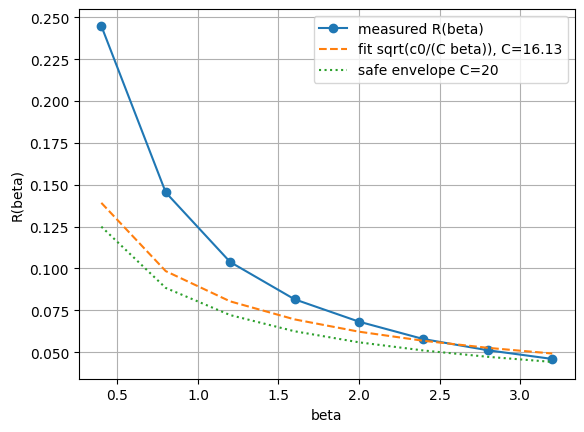

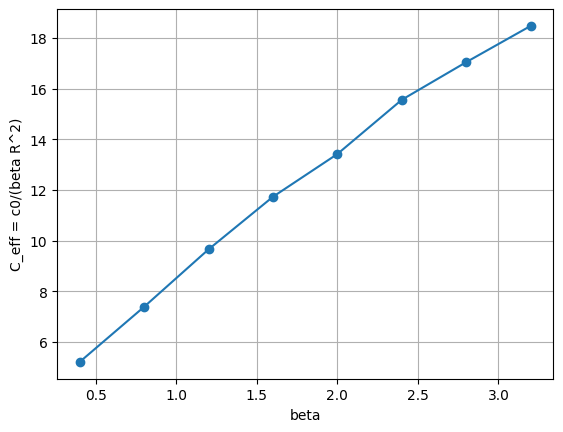

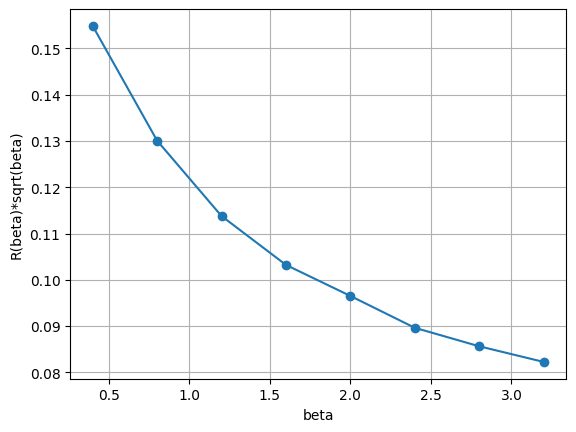

In [3]:
import numpy as np
import matplotlib.pyplot as plt

c0 = 0.125  # your normalization
R_curve = [
  (0.4, 0.2448828125),
  (0.8, 0.1454296875),
  (1.2, 0.1038671875),
  (1.6, 0.0816015625),
  (2.0, 0.0682421875),
  (2.4, 0.0578515625),
  (2.8, 0.051171875),
  (3.2, 0.0459765625),
]

betas = np.array([b for b,_ in R_curve])
R     = np.array([r for _,r in R_curve])

Ceff = c0 / (betas * R**2)
K    = R * np.sqrt(betas)   # should plateau if 1/sqrt(beta) scaling is right

print("beta    R(beta)      C_eff(beta)     R*sqrt(beta)")
for b,r,ce,k in zip(betas, R, Ceff, K):
    print(f"{b:4.1f}   {r:0.6f}     {ce:0.6f}      {k:0.6f}")

# Fit C on "more perturbative" tail (edit threshold as you like)
mask = betas >= 2.0
C_fit = Ceff[mask].mean()
print("\nC_fit (beta>=2) =", C_fit)

def R_model(beta, C):
    return np.sqrt(c0/(C*beta))

R_fit  = R_model(betas, C_fit)
R_safe = R_model(betas, 20.0)  # theorem-safe envelope candidate

plt.figure()
plt.plot(betas, R, 'o-', label='measured R(beta)')
plt.plot(betas, R_fit, '--', label=f'fit sqrt(c0/(C beta)), C={C_fit:.2f}')
plt.plot(betas, R_safe, ':', label='safe envelope C=20')
plt.xlabel('beta'); plt.ylabel('R(beta)')
plt.legend(); plt.grid(True); plt.show()

plt.figure()
plt.plot(betas, Ceff, 'o-')
plt.xlabel('beta'); plt.ylabel('C_eff = c0/(beta R^2)')
plt.grid(True); plt.show()

plt.figure()
plt.plot(betas, K, 'o-')
plt.xlabel('beta'); plt.ylabel('R(beta)*sqrt(beta)')
plt.grid(True); plt.show()

In [1]:
import math
import time
import argparse
import numpy as np
import torch
import torch.fft as fft


# -----------------------------
# Fit helpers (shell-average)
# -----------------------------
def shell_average(p2, G, tol=1e-12):
    # group by p2 value; use rounding to stabilize float equality
    key = np.round(p2 / tol).astype(np.int64)
    order = np.argsort(key)
    key = key[order]
    p2s = p2[order]
    Gs = G[order]

    shell_p2 = []
    shell_G = []
    shell_w = []

    i = 0
    n = len(key)
    while i < n:
        j = i + 1
        while j < n and key[j] == key[i]:
            j += 1
        shell_p2.append(float(p2s[i]))
        shell_G.append(float(Gs[i:j].mean()))
        shell_w.append(float(j - i))
        i = j

    return np.array(shell_p2, dtype=np.float64), np.array(shell_G, dtype=np.float64), np.array(shell_w, dtype=np.float64)


def fit_p2_p4_shells(p2_shell, G_shell, w_shell, ridge=1e-10):
    # Fit 1/G = a + b p2 + c p4 on shell-averaged points with multiplicity weights.
    y = 1.0 / G_shell
    p4 = p2_shell * p2_shell
    X = np.stack([np.ones_like(p2_shell), p2_shell, p4], axis=1)

    sw = np.sqrt(w_shell)
    Xw = X * sw[:, None]
    yw = y * sw

    A = Xw.T @ Xw + ridge * np.eye(3, dtype=np.float64)
    b = Xw.T @ yw
    c = np.linalg.solve(A, b)
    cond = np.linalg.cond(X)
    return c, cond  # [m,Z,gamma], cond


# -----------------------------
# FFT lattice operators
# -----------------------------
def make_phat_1d(L: int, a: float, device: str, dtype: torch.dtype):
    f = torch.fft.fftfreq(L, d=1.0, device=device, dtype=dtype)
    return (2.0 / a) * torch.sin(math.pi * f)


def make_pgrids(ph: torch.Tensor):
    L = ph.numel()
    p0 = ph.view(L, 1, 1, 1)
    p1 = ph.view(1, L, 1, 1)
    p2 = ph.view(1, 1, L, 1)
    p3 = ph.view(1, 1, 1, L)
    return p0, p1, p2, p3


def project_perp_and_cc(A: torch.Tensor, p0, p1, p2, p3, eps=1e-12):
    spatial = (-4, -3, -2, -1)
    Ahat = fft.fftn(A, dim=spatial, norm="ortho")  # complex
    p2grid = (p0 * p0 + p1 * p1 + p2 * p2 + p3 * p3)

    dot = (p0 * Ahat[:, 0] + p1 * Ahat[:, 1] + p2 * Ahat[:, 2] + p3 * Ahat[:, 3])

    inv = torch.zeros_like(p2grid)
    mask = p2grid > 0
    inv[mask] = 1.0 / (p2grid[mask] + eps)

    factor = dot * inv
    Aperp = torch.stack(
        [
            Ahat[:, 0] - p0 * factor,
            Ahat[:, 1] - p1 * factor,
            Ahat[:, 2] - p2 * factor,
            Ahat[:, 3] - p3 * factor,
        ],
        dim=1,
    )

    cc_hat = Aperp * p2grid
    ccA = fft.ifftn(cc_hat, dim=spatial, norm="ortho").real
    return ccA, Aperp, p2grid


def pick_lowk_from_p2grid(p2grid, K):
    p2_flat = p2grid.reshape(-1).detach().cpu().numpy()
    mask = p2_flat > 0
    idx_all = np.nonzero(mask)[0]
    idx_sort = idx_all[np.argsort(p2_flat[idx_all])]
    idx = idx_sort[: int(K)].astype(np.int64)
    return p2_flat, idx


def relerr(x, targ):
    x = np.asarray(x, dtype=np.float64)
    targ = np.asarray(targ, dtype=np.float64)
    return np.abs(x - targ) / (np.abs(targ) + 1e-12)


def loss(x, targ):
    r = relerr(x, targ)
    return float(np.sqrt(np.mean(r * r)))


def damped_step(J, f, reg):
    JTJ = J.T @ J
    A = JTJ + float(reg) * np.eye(JTJ.shape[0], dtype=np.float64)
    b = J.T @ f
    return np.linalg.solve(A, b)


# -----------------------------
# CRN evaluator
# -----------------------------
@torch.no_grad()
def eval_eff_crn(
    Lc, batch, m2, alpha, beta, lam4,
    dt, steps, burnin, thin,
    K, device, dtype, init_sigma,
    seed_init, seed_noise,
    ridge_fit=1e-10
):
    d = 4
    a = 2.0

    ph = make_phat_1d(Lc, a=a, device=device, dtype=dtype)
    p0, p1, p2, p3 = make_pgrids(ph)

    gen_init = torch.Generator(device=device).manual_seed(int(seed_init))
    A = init_sigma * torch.randn((batch, d, Lc, Lc, Lc, Lc), device=device, dtype=dtype, generator=gen_init)

    # low-k indices (ascending p2)
    _, _, p2grid = project_perp_and_cc(A[:1], p0, p1, p2, p3)
    p2_flat, lowk_idx = pick_lowk_from_p2grid(p2grid, K)
    p2_order = p2_flat[lowk_idx]  # p2 aligned to Pk_mean order

    gen_noise = torch.Generator(device=device).manual_seed(int(seed_noise))
    sqrt_2dt = math.sqrt(2.0 * dt)

    Pk_acc = np.zeros((len(lowk_idx),), dtype=np.float64)
    nsamp = 0

    for t in range(steps):
        ccA, _, _ = project_perp_and_cc(A, p0, p1, p2, p3)
        cc2A, _, _ = project_perp_and_cc(ccA, p0, p1, p2, p3)

        grad = (m2 * A) + (alpha * ccA) + (beta * cc2A) + (lam4 * (A ** 3))
        noise = torch.randn(A.shape, device=device, dtype=dtype, generator=gen_noise)
        A = A - dt * grad + sqrt_2dt * noise

        if t >= burnin and ((t - burnin) % thin == 0):
            _, Aperp_hat, _ = project_perp_and_cc(A, p0, p1, p2, p3)
            Ap = Aperp_hat.reshape(batch, d, -1)
            P = (Ap.real * Ap.real + Ap.imag * Ap.imag).mean(dim=(0, 1))
            Pk_acc += P.reshape(-1)[lowk_idx].detach().cpu().numpy()
            nsamp += 1

    if nsamp == 0:
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64), np.nan, 0

    Pk_mean = Pk_acc / nsamp

    # shell-average fit
    p2_shell, G_shell, w_shell = shell_average(p2_order.astype(np.float64), Pk_mean.astype(np.float64))
    if len(p2_shell) < 6:
        # refuse: not enough distinct shells to identify p^4 stably
        return np.array([np.nan, np.nan, np.nan], dtype=np.float64), np.nan, int(len(p2_shell))

    c, cond = fit_p2_p4_shells(p2_shell, G_shell, w_shell, ridge=ridge_fit)
    return c, float(cond), int(len(p2_shell))


# -----------------------------
# Main matcher
# -----------------------------
def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--inp", type=str, default="unified_v3_p4_stats.npz")

    p.add_argument("--device", type=str, default="cuda")
    p.add_argument("--dtype", type=str, default="float32", choices=["float32", "float64"])

    # matching target uses K=256 by default (your own table says this is the only sane one)
    p.add_argument("--K", type=int, default=256)

    # eval controls
    p.add_argument("--steps", type=int, default=4000)   # cheaper inner loop
    p.add_argument("--burnin", type=int, default=1200)
    p.add_argument("--thin", type=int, default=20)
    p.add_argument("--dt", type=float, default=5e-4)
    p.add_argument("--batch", type=int, default=16)
    p.add_argument("--init_sigma", type=float, default=0.20)

    # final verification controls (longer)
    p.add_argument("--steps_final", type=int, default=8000)
    p.add_argument("--burnin_final", type=int, default=2000)
    p.add_argument("--thin_final", type=int, default=20)

    # match loop
    p.add_argument("--iters", type=int, default=8)
    p.add_argument("--tol", type=float, default=0.02)
    p.add_argument("--damping", type=float, default=1.0)
    p.add_argument("--reg_step", type=float, default=1e-2)
    p.add_argument("--du", type=float, default=0.06)   # log-steps
    p.add_argument("--max_backtrack", type=int, default=4)
    p.add_argument("--ridge_fit", type=float, default=1e-10)

    # lam4 fixed from file unless overridden
    p.add_argument("--lam4", type=float, default=np.nan)

    # init guesses (defaults from target)
    p.add_argument("--m2_init", type=float, default=np.nan)
    p.add_argument("--alpha_init", type=float, default=np.nan)
    p.add_argument("--beta_init", type=float, default=np.nan)

    # CRN seeds
    p.add_argument("--seed_init", type=int, default=12345)
    p.add_argument("--seed_noise", type=int, default=67890)

    p.add_argument("--out", type=str, default="rg_match_p4_shell_crn.npz")

    args, _ = p.parse_known_args()
    return args


def main():
    args = parse_args()

    if args.device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA requested but not available")

    device = args.device
    dtype = torch.float32 if args.dtype == "float32" else torch.float64

    dat = np.load(args.inp, allow_pickle=False)
    Lc = int(dat["Lc"])
    lam4_file = float(dat["lam4"])
    lam4 = lam4_file if np.isnan(args.lam4) else float(args.lam4)

    # TARGET: compute from stored block-RG spectrum in a stable way
    p2_flat_c = dat["p2_flat_c"].astype(np.float64)
    idx_c_full = dat["lowk_idx_c"].astype(np.int64)
    Gbr_full = dat["Pk_mean_br"].astype(np.float64)
    K = int(min(args.K, len(Gbr_full), len(idx_c_full)))

    p2_order = p2_flat_c[idx_c_full[:K]]
    Gbr = Gbr_full[:K]
    p2_shell, G_shell, w_shell = shell_average(p2_order, Gbr)
    if len(p2_shell) < 6:
        raise RuntimeError(f"Target fit refused: only {len(p2_shell)} shells in K={K} (need >=6).")
    targ, condT = fit_p2_p4_shells(p2_shell, G_shell, w_shell, ridge=args.ridge_fit)

    print("\n================= TARGET (shell-fit) =================")
    print(f"Lc={Lc}  K={K}  shells={len(p2_shell)}  cond(X)={condT:.2e}  lam4={lam4}")
    print(f"target (m_eff2,Z,gamma)=({targ[0]:.6g},{targ[1]:.6g},{targ[2]:.6g})")
    print("======================================================\n")

    # init guesses and log-parametrize to keep m2,alpha,beta > 0
    m2_0 = float(targ[0]) if np.isnan(args.m2_init) else float(args.m2_init)
    a_0  = float(targ[1]) if np.isnan(args.alpha_init) else float(args.alpha_init)
    b_0  = max(float(targ[2]), 1e-6) if np.isnan(args.beta_init) else float(args.beta_init)

    u = math.log(max(m2_0, 1e-6))
    v = math.log(max(a_0, 1e-6))
    w = math.log(max(b_0, 1e-6))

    hist = []

    for it in range(args.iters):
        t0 = time.time()

        m2 = math.exp(u); alpha = math.exp(v); beta = math.exp(w)

        base, condB, shellsB = eval_eff_crn(
            Lc, args.batch, m2, alpha, beta, lam4,
            args.dt, args.steps, args.burnin, args.thin,
            K, device, dtype, args.init_sigma,
            args.seed_init, args.seed_noise,
            ridge_fit=args.ridge_fit
        )
        if not np.all(np.isfinite(base)):
            print(f"[it {it}] eval failed (base nonfinite). Stop.")
            break

        f0 = base - targ
        r0 = relerr(base, targ)
        L0 = loss(base, targ)

        print(f"[it {it}] (m2,alpha,beta)=({m2:.6g},{alpha:.6g},{beta:.6g})  shells={shellsB} cond={condB:.2e}")
        print(f"        eff=({base[0]:.6g},{base[1]:.6g},{base[2]:.6g})")
        print(f"        relerr=({r0[0]*100:.2f}%,{r0[1]*100:.2f}%,{r0[2]*100:.2f}%)  loss={L0:.4g}  wall={time.time()-t0:.1f}s\n")

        hist.append([it, m2, alpha, beta, base[0], base[1], base[2], r0[0], r0[1], r0[2], L0])

        if np.all(r0 < args.tol):
            print("[stop] tolerance met.\n")
            break

        du = float(args.du); dv = float(args.du); dw = float(args.du)

        e_u, _, _ = eval_eff_crn(Lc, args.batch, math.exp(u+du), math.exp(v), math.exp(w), lam4,
                                 args.dt, args.steps, args.burnin, args.thin, K,
                                 device, dtype, args.init_sigma, args.seed_init, args.seed_noise, args.ridge_fit)
        e_v, _, _ = eval_eff_crn(Lc, args.batch, math.exp(u), math.exp(v+dv), math.exp(w), lam4,
                                 args.dt, args.steps, args.burnin, args.thin, K,
                                 device, dtype, args.init_sigma, args.seed_init, args.seed_noise, args.ridge_fit)
        e_w, _, _ = eval_eff_crn(Lc, args.batch, math.exp(u), math.exp(v), math.exp(w+dw), lam4,
                                 args.dt, args.steps, args.burnin, args.thin, K,
                                 device, dtype, args.init_sigma, args.seed_init, args.seed_noise, args.ridge_fit)

        J = np.column_stack([(e_u - base)/du, (e_v - base)/dv, (e_w - base)/dw])  # 3x3
        dx = damped_step(J, f0, args.reg_step)

        accepted = False
        step = float(args.damping)
        for _ in range(args.max_backtrack + 1):
            u_try = u - step*dx[0]
            v_try = v - step*dx[1]
            w_try = w - step*dx[2]

            trial, _, _ = eval_eff_crn(
                Lc, args.batch, math.exp(u_try), math.exp(v_try), math.exp(w_try), lam4,
                args.dt, args.steps, args.burnin, args.thin,
                K, device, dtype, args.init_sigma,
                args.seed_init, args.seed_noise,
                ridge_fit=args.ridge_fit
            )
            L_try = loss(trial, targ)
            if np.isfinite(L_try) and (L_try < L0):
                accepted = True
                u, v, w = u_try, v_try, w_try
                break
            step *= 0.5

        if not accepted:
            print("[warn] no improving step found; stop.\n")
            break

    # Final verification with fresh noise + longer run
    m2 = math.exp(u); alpha = math.exp(v); beta = math.exp(w)
    final, condF, shellsF = eval_eff_crn(
        Lc, args.batch, m2, alpha, beta, lam4,
        args.dt, args.steps_final, args.burnin_final, args.thin_final,
        K, device, dtype, args.init_sigma,
        args.seed_init + 999, args.seed_noise + 999,
        ridge_fit=args.ridge_fit
    )
    rF = relerr(final, targ)

    print("================= FINAL (fresh noise, long) =================")
    print(f"(m2,alpha,beta)=({m2:.6g},{alpha:.6g},{beta:.6g})  shells={shellsF} cond={condF:.2e}")
    print(f"eff=({final[0]:.6g},{final[1]:.6g},{final[2]:.6g})")
    print(f"target=({targ[0]:.6g},{targ[1]:.6g},{targ[2]:.6g})")
    print(f"relerr=({rF[0]*100:.2f}%,{rF[1]*100:.2f}%,{rF[2]*100:.2f}%)")
    print("=============================================================\n")

    np.savez(
        args.out,
        Lc=Lc, K=K, lam4=lam4,
        target=targ, cond_target=condT, shells_target=len(p2_shell),
        hist=np.array(hist, dtype=np.float64),
        m2_final=m2, alpha_final=alpha, beta_final=beta,
        eff_final=final, relerr_final=rF,
        steps=args.steps, burnin=args.burnin, thin=args.thin,
        steps_final=args.steps_final, burnin_final=args.burnin_final, thin_final=args.thin_final,
        dt=args.dt, batch=args.batch, init_sigma=args.init_sigma,
        seed_init=args.seed_init, seed_noise=args.seed_noise,
        reg_step=args.reg_step, ridge_fit=args.ridge_fit, damping=args.damping, tol=args.tol
    )
    print(f"[saved] {args.out}")


if __name__ == "__main__":
    main()

FileNotFoundError: [Errno 2] No such file or directory: 'unified_v3_p4_stats.npz'

In [ ]:
import math
import os
import time
import argparse
import numpy as np
import torch
import torch.fft as fft


# ----------------------------
# Utilities
# ----------------------------
def parse_args():
    p = argparse.ArgumentParser()

    # lattice / sim
    p.add_argument("--L", type=int, default=32)
    p.add_argument("--batch", type=int, default=8)

    p.add_argument("--m2", type=float, default=0.30)
    p.add_argument("--alpha", type=float, default=1.0)
    p.add_argument("--lam4", type=float, default=0.50)

    p.add_argument("--dt", type=float, default=5e-4)
    p.add_argument("--steps", type=int, default=6000)
    p.add_argument("--burnin", type=int, default=1500)
    p.add_argument("--thin", type=int, default=20)

    p.add_argument("--init_sigma", type=float, default=0.20)

    # RG / blocking
    p.add_argument("--rg_field_scale", type=float, default=2.0)

    # spectrum fit
    p.add_argument("--lowk", type=int, default=256)

    # device
    p.add_argument("--device", type=str, default="cuda")
    p.add_argument("--dtype", type=str, default="float32", choices=["float32", "float64"])

    # RNG
    p.add_argument("--seed", type=int, default=0)
    p.add_argument("--seed_init", type=int, default=12345)
    p.add_argument("--seed_noise", type=int, default=67890)

    # output
    p.add_argument("--out", type=str, default="unified_v3_p4_stats.npz")

    args, _ = p.parse_known_args()
    return args


def set_seed(seed: int):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)


def make_phat_1d(L: int, a: float, device: str, dtype: torch.dtype):
    # p̂ = (2/a) sin(pi k/L), with k represented by fftfreq
    f = torch.fft.fftfreq(L, d=1.0, device=device, dtype=dtype)
    return (2.0 / a) * torch.sin(math.pi * f)


def make_pgrids(ph: torch.Tensor):
    L = ph.numel()
    p0 = ph.view(L, 1, 1, 1)
    p1 = ph.view(1, L, 1, 1)
    p2 = ph.view(1, 1, L, 1)
    p3 = ph.view(1, 1, 1, L)
    return p0, p1, p2, p3


def project_perp_and_curlcurl(A: torch.Tensor, p0, p1, p2, p3, eps=1e-12):
    # A: (B, d=4, L,L,L,L)
    spatial = (-4, -3, -2, -1)
    Ahat = fft.fftn(A, dim=spatial, norm="ortho")  # complex
    p2grid = (p0 * p0 + p1 * p1 + p2 * p2 + p3 * p3)

    dot = (p0 * Ahat[:, 0] + p1 * Ahat[:, 1] + p2 * Ahat[:, 2] + p3 * Ahat[:, 3])

    inv = torch.zeros_like(p2grid)
    mask = p2grid > 0
    inv[mask] = 1.0 / (p2grid[mask] + eps)
    factor = dot * inv

    Aperp_hat = torch.stack(
        [
            Ahat[:, 0] - p0 * factor,
            Ahat[:, 1] - p1 * factor,
            Ahat[:, 2] - p2 * factor,
            Ahat[:, 3] - p3 * factor,
        ],
        dim=1,
    )

    curlcurl_hat = Aperp_hat * p2grid
    curlcurlA = fft.ifftn(curlcurl_hat, dim=spatial, norm="ortho").real
    return curlcurlA, Aperp_hat, p2grid


def block2_avg(A):
    # average 2x2x2x2 blocks => L -> L/2
    B, d, L, _, _, _ = A.shape
    assert L % 2 == 0
    Lc = L // 2
    return A.reshape(B, d, Lc, 2, Lc, 2, Lc, 2, Lc, 2).mean(dim=(3, 5, 7, 9))


def pick_lowk(p2grid_torch, K):
    p2_flat = p2grid_torch.reshape(-1).detach().cpu().numpy()
    mask = p2_flat > 0
    idx_all = np.nonzero(mask)[0]
    idx_sort = idx_all[np.argsort(p2_flat[idx_all])]
    lowk_idx = idx_sort[: int(K)].astype(np.int64)
    return p2_flat, lowk_idx


def fit_invprop_p2_p4(Pk_mean, p2_flat, lowk_idx):
    # Fit: 1/G = a + b p2 + c p4
    G = np.asarray(Pk_mean, dtype=np.float64)
    p2 = np.asarray(p2_flat[lowk_idx], dtype=np.float64)
    p4 = p2 * p2

    good = (G > 0) & np.isfinite(G) & np.isfinite(p2)
    G, p2, p4 = G[good], p2[good], p4[good]

    if G.size < 12:
        return dict(m_eff2=np.nan, Z=np.nan, gamma=np.nan, n=int(G.size))

    y = 1.0 / G
    X = np.stack([np.ones_like(p2), p2, p4], axis=1)
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)

    return dict(m_eff2=float(coef[0]), Z=float(coef[1]), gamma=float(coef[2]), n=int(G.size))


def cat_list(xs):
    return np.concatenate(xs, axis=0) if xs else np.empty((0,), dtype=np.float64)


# ----------------------------
# Main
# ----------------------------
def main():
    args = parse_args()

    if args.device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA requested but not available")

    device = args.device
    dtype = torch.float32 if args.dtype == "float32" else torch.float64

    set_seed(args.seed)

    L = int(args.L)
    assert L % 2 == 0
    Lc = L // 2
    d = 4
    B = int(args.batch)

    # fine (a=1) and coarse (a'=2)
    ph_f = make_phat_1d(L, a=1.0, device=device, dtype=dtype)
    p0, p1, p2, p3 = make_pgrids(ph_f)

    ph_c = make_phat_1d(Lc, a=2.0, device=device, dtype=dtype)
    q0, q1, q2, q3 = make_pgrids(ph_c)

    # init field with explicit generator
    gen_init = torch.Generator(device=device).manual_seed(int(args.seed_init))
    A = args.init_sigma * torch.randn((B, d, L, L, L, L), device=device, dtype=dtype, generator=gen_init)

    # low-k indices (fine and coarse)
    with torch.no_grad():
        _, _, p2grid_f = project_perp_and_curlcurl(A[:1], p0, p1, p2, p3)
        p2_flat_f, lowk_idx_f = pick_lowk(p2grid_f, args.lowk)

        Ab0 = block2_avg(A[:1])
        _, _, p2grid_c = project_perp_and_curlcurl(Ab0, q0, q1, q2, q3)
        p2_flat_c, lowk_idx_c = pick_lowk(p2grid_c, args.lowk)

    # accumulators for operator stats
    N2_f, C1_f, C2_f, N4_f = [], [], [], []
    N2_bn, C1_bn, C2_bn, N4_bn = [], [], [], []
    N2_br, C1_br, C2_br, N4_br = [], [], [], []

    # spectra accumulators (already aligned to lowk_idx ordering)
    Pk_f = np.zeros((len(lowk_idx_f),), dtype=np.float64)
    Pk_bn = np.zeros((len(lowk_idx_c),), dtype=np.float64)
    Pk_br = np.zeros((len(lowk_idx_c),), dtype=np.float64)

    gen_noise = torch.Generator(device=device).manual_seed(int(args.seed_noise))
    sqrt_2dt = math.sqrt(2.0 * args.dt)

    nsamp = 0
    t0 = time.time()

    for t in range(args.steps):
        # Langevin step on fine field
        curlcurlA, _, _ = project_perp_and_curlcurl(A, p0, p1, p2, p3)
        gradS = args.m2 * A + args.alpha * curlcurlA + args.lam4 * (A ** 3)
        noise = torch.randn(A.shape, device=device, dtype=dtype, generator=gen_noise)
        A = A - args.dt * gradS + sqrt_2dt * noise

        if t >= args.burnin and ((t - args.burnin) % args.thin == 0):
            with torch.no_grad():
                # ---- fine ----
                curlcurlA, Aperp_hat, _ = project_perp_and_curlcurl(A, p0, p1, p2, p3)
                N2 = (A * A).flatten(1).sum(-1)
                C1 = (A * curlcurlA).flatten(1).sum(-1)
                C2 = (curlcurlA * curlcurlA).flatten(1).sum(-1)
                N4 = (A ** 4).flatten(1).sum(-1)

                N2_f.append(N2.cpu().numpy())
                C1_f.append(C1.cpu().numpy())
                C2_f.append(C2.cpu().numpy())
                N4_f.append(N4.cpu().numpy())

                Ap = Aperp_hat.reshape(B, d, -1)
                P = (Ap.real * Ap.real + Ap.imag * Ap.imag).mean(dim=(0, 1))
                Pk_f += P[lowk_idx_f].cpu().numpy()

                # ---- block naive ----
                Abn = block2_avg(A)
                curlbn, Aperp_bn, _ = project_perp_and_curlcurl(Abn, q0, q1, q2, q3)

                N2n = (Abn * Abn).flatten(1).sum(-1)
                C1n = (Abn * curlbn).flatten(1).sum(-1)
                C2n = (curlbn * curlbn).flatten(1).sum(-1)
                N4n = (Abn ** 4).flatten(1).sum(-1)

                N2_bn.append(N2n.cpu().numpy())
                C1_bn.append(C1n.cpu().numpy())
                C2_bn.append(C2n.cpu().numpy())
                N4_bn.append(N4n.cpu().numpy())

                Apn = Aperp_bn.reshape(B, d, -1)
                Pn = (Apn.real * Apn.real + Apn.imag * Apn.imag).mean(dim=(0, 1))
                Pk_bn += Pn[lowk_idx_c].cpu().numpy()

                # ---- block RG (field rescale) ----
                Abr = args.rg_field_scale * Abn
                curlbr, Aperp_br, _ = project_perp_and_curlcurl(Abr, q0, q1, q2, q3)

                N2r = (Abr * Abr).flatten(1).sum(-1)
                C1r = (Abr * curlbr).flatten(1).sum(-1)
                C2r = (curlbr * curlbr).flatten(1).sum(-1)
                N4r = (Abr ** 4).flatten(1).sum(-1)

                N2_br.append(N2r.cpu().numpy())
                C1_br.append(C1r.cpu().numpy())
                C2_br.append(C2r.cpu().numpy())
                N4_br.append(N4r.cpu().numpy())

                Apr = Aperp_br.reshape(B, d, -1)
                Pr = (Apr.real * Apr.real + Apr.imag * Apr.imag).mean(dim=(0, 1))
                Pk_br += Pr[lowk_idx_c].cpu().numpy()

                nsamp += 1

        if (t + 1) % max(200, args.thin * 10) == 0:
            print(f"[step {t+1}/{args.steps}] nsamp={nsamp}  wall={time.time()-t0:.1f}s")

    if nsamp > 0:
        Pk_f /= nsamp
        Pk_bn /= nsamp
        Pk_br /= nsamp

    # stack operator stats
    N2_f = cat_list(N2_f); C1_f = cat_list(C1_f); C2_f = cat_list(C2_f); N4_f = cat_list(N4_f)
    N2_bn = cat_list(N2_bn); C1_bn = cat_list(C1_bn); C2_bn = cat_list(C2_bn); N4_bn = cat_list(N4_bn)
    N2_br = cat_list(N2_br); C1_br = cat_list(C1_br); C2_br = cat_list(C2_br); N4_br = cat_list(N4_br)

    fit_f = fit_invprop_p2_p4(Pk_f, p2_flat_f, lowk_idx_f)
    fit_bn = fit_invprop_p2_p4(Pk_bn, p2_flat_c, lowk_idx_c)
    fit_br = fit_invprop_p2_p4(Pk_br, p2_flat_c, lowk_idx_c)

    print("\n================= P2+P4 FIT =================")
    print(f"[fine]       m_eff2={fit_f['m_eff2']:.6g}  Z={fit_f['Z']:.6g}  gamma={fit_f['gamma']:.6g}  n={fit_f['n']}")
    print(f"[block naive] m_eff2={fit_bn['m_eff2']:.6g}  Z={fit_bn['Z']:.6g}  gamma={fit_bn['gamma']:.6g}  n={fit_bn['n']}")
    print(f"[block RG]    m_eff2={fit_br['m_eff2']:.6g}  Z={fit_br['Z']:.6g}  gamma={fit_br['gamma']:.6g}  n={fit_br['n']}")
    print("=============================================\n")

    out_path = os.path.abspath(args.out)
    np.savez(
        out_path,
        # metadata
        L=L, Lc=Lc, d=d, batch=B, nsamp=nsamp,
        m2=args.m2, alpha=args.alpha, lam4=args.lam4,
        dt=args.dt, steps=args.steps, burnin=args.burnin, thin=args.thin,
        init_sigma=args.init_sigma,
        rg_field_scale=args.rg_field_scale,
        lowk=args.lowk,
        seed=args.seed, seed_init=args.seed_init, seed_noise=args.seed_noise,

        # lowk ordering + spectra (aligned!)
        p2_flat=p2_flat_f, lowk_idx=lowk_idx_f, Pk_mean=Pk_f,
        p2_flat_c=p2_flat_c, lowk_idx_c=lowk_idx_c, Pk_mean_bn=Pk_bn, Pk_mean_br=Pk_br,

        # p2+p4 fits (these are what you were matching)
        m_eff2_f=fit_f["m_eff2"], Z_f=fit_f["Z"], gamma_f=fit_f["gamma"],
        m_eff2_bn=fit_bn["m_eff2"], Z_bn=fit_bn["Z"], gamma_bn=fit_bn["gamma"],
        m_eff2_br=fit_br["m_eff2"], Z_br=fit_br["Z"], gamma_br=fit_br["gamma"],

        # operator stats (per sample)
        N2_f=N2_f, C1_f=C1_f, C2_f=C2_f, N4_f=N4_f,
        N2_bn=N2_bn, C1_bn=C1_bn, C2_bn=C2_bn, N4_bn=N4_bn,
        N2_br=N2_br, C1_br=C1_br, C2_br=C2_br, N4_br=N4_br,
    )
    print(f"[saved] {out_path}")


if __name__ == "__main__":
    main()

[step 200/6000] nsamp=0  wall=2.3s
[step 400/6000] nsamp=0  wall=4.5s
[step 600/6000] nsamp=0  wall=6.7s
[step 800/6000] nsamp=0  wall=8.9s
[step 1000/6000] nsamp=0  wall=11.1s
[step 1200/6000] nsamp=0  wall=13.3s
[step 1400/6000] nsamp=0  wall=15.5s
[step 1600/6000] nsamp=5  wall=17.8s
[step 1800/6000] nsamp=15  wall=20.2s
[step 2000/6000] nsamp=25  wall=22.6s
[step 2200/6000] nsamp=35  wall=24.9s
[step 2400/6000] nsamp=45  wall=27.3s
[step 2600/6000] nsamp=55  wall=29.7s
[step 2800/6000] nsamp=65  wall=32.0s
[step 3000/6000] nsamp=75  wall=34.4s
[step 3200/6000] nsamp=85  wall=36.8s
[step 3400/6000] nsamp=95  wall=39.1s
[step 3600/6000] nsamp=105  wall=41.5s
[step 3800/6000] nsamp=115  wall=43.9s
[step 4000/6000] nsamp=125  wall=46.2s
[step 4200/6000] nsamp=135  wall=48.6s
[step 4400/6000] nsamp=145  wall=51.0s
[step 4600/6000] nsamp=155  wall=53.3s
[step 4800/6000] nsamp=165  wall=55.7s
[step 5000/6000] nsamp=175  wall=58.1s
[step 5200/6000] nsamp=185  wall=60.4s
[step 5400/6000] ns